In [2]:
import gc
import time
import warnings
from itertools import combinations
from pathlib import Path #pour la gestion des chemins de fichiers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.feature_extraction.text import CountVectorizer

from umap import UMAP
from hdbscan import HDBSCAN
from hdbscan.validity import validity_index

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer #pour les embeddings de phrase

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel


warnings.filterwarnings("ignore")


# ------------------------------------------------------------------
# À adapter uniquement si tes colonnes portent d'autres noms
# ------------------------------------------------------------------

COL_TEXTE = "phrases_lemm"
COL_ROMAN = "roman"

RANDOM_STATE = 42

# Calculer DBCV peut ralentir légèrement la grille.
CALCULER_DBCV = True

# Nombre maximal de documents utilisés pour la silhouette.
TAILLE_ECHANTILLON_SILHOUETTE = 2000

In [11]:
df=pd.read_csv(Path("..")/"data" /"2_processed"/"03_corpus_lematise.csv", encoding="utf-8")

embedding_model = SentenceTransformer(
    "dangvantuan/sentence-camembert-base"
)

print("Génération des embeddings sémantiques...")
embeddings = embedding_model.encode(df['texte'].tolist(),batch_size=64, show_progress_bar=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Génération des embeddings sémantiques...


Batches:   0%|          | 0/84 [00:00<?, ?it/s]

In [12]:
# Vérification des colonnes
assert COL_TEXTE in df.columns, (
    f"La colonne '{COL_TEXTE}' n'existe pas dans df."
)
assert COL_ROMAN in df.columns, (
    f"La colonne '{COL_ROMAN}' n'existe pas dans df."
)

# Conversion des embeddings
embeddings_array_initial = np.asarray(embeddings)

assert len(df) == len(embeddings_array_initial), (
    "Le nombre de lignes de df ne correspond pas "
    "au nombre d'embeddings."
)

# Masque des documents non vides
masque_documents = (
    df[COL_TEXTE].notna()
    & df[COL_TEXTE].astype(str).str.strip().ne("")
)

# DataFrame utilisé par BERTopic
df_model = (
    df.loc[masque_documents]
    .copy()
    .reset_index(drop=True)
)

# Documents
documents = (
    df_model[COL_TEXTE]
    .astype(str)
    .tolist()
)

# Romans associés aux documents
romans = (
    df_model[COL_ROMAN]
    .astype(str)
    .tolist()
)

# Embeddings alignés
embeddings_array = embeddings_array_initial[
    masque_documents.to_numpy()
]

# Tokenisation simple pour la cohérence C_v
texts_tokenises = [
    document.split()
    for document in documents
]

# Dictionnaire Gensim
dictionary = Dictionary(texts_tokenises)


print("Nombre de documents :", len(documents))
print("Nombre de romans :", df_model[COL_ROMAN].nunique())
print("Dimensions des embeddings :", embeddings_array.shape)
print("Taille du dictionnaire :", len(dictionary))

Nombre de documents : 5327
Nombre de romans : 31
Dimensions des embeddings : (5327, 768)
Taille du dictionnaire : 19186


In [13]:
def extraire_mots_topics(
    topic_model,
    labels,
    top_n_words=10,
    dictionary=None
):
    """
    Extrait les mots des topics, en excluant le topic -1.

    Si un dictionnaire Gensim est fourni, seuls les mots présents
    dans ce dictionnaire sont conservés.
    """

    labels = np.asarray(labels)

    topic_ids = sorted(
        int(topic_id)
        for topic_id in np.unique(labels)
        if topic_id != -1
    )

    topics_words = []

    for topic_id in topic_ids:

        representation = topic_model.get_topic(topic_id)

        if not representation:
            continue

        words = [
            word
            for word, _ in representation[:top_n_words]
        ]

        if dictionary is not None:
            words = [
                word
                for word in words
                if word in dictionary.token2id
            ]

        # Éviter les topics insuffisamment représentés
        if len(words) >= 2:
            topics_words.append(words)

    return topics_words

In [14]:
def calculer_coherence_cv(
    topic_model,
    labels,
    texts_tokenises,
    dictionary,
    top_n_words=10
):
    """
    Calcule la cohérence C_v des topics BERTopic.
    """

    topics_words = extraire_mots_topics(
        topic_model=topic_model,
        labels=labels,
        top_n_words=top_n_words,
        dictionary=dictionary
    )

    if len(topics_words) < 2:
        return np.nan

    try:
        coherence_model = CoherenceModel(
            topics=topics_words,
            texts=texts_tokenises,
            dictionary=dictionary,
            coherence="c_v",
            topn=top_n_words,
            processes=1
        )

        return float(coherence_model.get_coherence())

    except Exception:
        return np.nan

In [15]:
def calculer_diversite_topics(
    topic_model,
    labels,
    top_n_words=10
):
    """
    Diversité lexicale :
    nombre de termes uniques / nombre total de termes.
    """

    topics_words = extraire_mots_topics(
        topic_model=topic_model,
        labels=labels,
        top_n_words=top_n_words,
        dictionary=None
    )

    tous_les_mots = [
        word
        for topic_words in topics_words
        for word in topic_words
    ]

    if not tous_les_mots:
        return np.nan

    return len(set(tous_les_mots)) / len(tous_les_mots)

In [16]:
def evaluer_modele(
    topic_model,
    topics,
    texts_tokenises,
    dictionary,
    silhouette_sample_size=2000,
    calculer_dbcv=True
):
    """
    Évalue un modèle BERTopic sur les topics bruts produits
    par HDBSCAN, avant toute réduction des outliers.
    """

    labels = np.asarray(topics, dtype=int)

    # Coordonnées UMAP utilisées par HDBSCAN
    embeddings_umap = np.asarray(
        topic_model.umap_model.embedding_,
        dtype=np.float64
    )

    masque_valides = labels != -1

    labels_valides = labels[masque_valides]
    embeddings_valides = embeddings_umap[masque_valides]

    topic_ids = np.unique(labels_valides)
    nombre_topics = len(topic_ids)

    nombre_documents = len(labels)
    nombre_assignes = int(masque_valides.sum())

    taux_outliers = float(np.mean(labels == -1))
    couverture = 1 - taux_outliers

    # --------------------------------------------------------------
    # Tailles des topics
    # --------------------------------------------------------------

    if nombre_topics > 0:

        tailles_topics = (
            pd.Series(labels_valides)
            .value_counts()
        )

        taille_min = int(tailles_topics.min())
        taille_mediane = float(tailles_topics.median())
        taille_max = int(tailles_topics.max())

        largest_topic_share = (
            taille_max / nombre_assignes
            if nombre_assignes > 0
            else np.nan
        )

    else:

        taille_min = np.nan
        taille_mediane = np.nan
        taille_max = np.nan
        largest_topic_share = np.nan

    # --------------------------------------------------------------
    # Silhouette dans l'espace UMAP
    # --------------------------------------------------------------

    silhouette = np.nan

    condition_silhouette = (
        nombre_topics >= 2
        and nombre_assignes > nombre_topics
    )

    if condition_silhouette:

        try:

            if nombre_assignes > silhouette_sample_size:

                silhouette = silhouette_score(
                    embeddings_valides,
                    labels_valides,
                    metric="euclidean",
                    sample_size=silhouette_sample_size,
                    random_state=RANDOM_STATE
                )

            else:

                silhouette = silhouette_score(
                    embeddings_valides,
                    labels_valides,
                    metric="euclidean"
                )

        except Exception:
            silhouette = np.nan

    # --------------------------------------------------------------
    # DBCV
    # --------------------------------------------------------------

    dbcv = np.nan

    if calculer_dbcv and nombre_topics >= 2:

        try:
            dbcv = validity_index(
                embeddings_umap,
                labels,
                metric="euclidean"
            )

            dbcv = float(dbcv)

        except Exception:
            dbcv = np.nan

    # --------------------------------------------------------------
    # Cohérence et diversité
    # --------------------------------------------------------------

    coherence_cv = calculer_coherence_cv(
        topic_model=topic_model,
        labels=labels,
        texts_tokenises=texts_tokenises,
        dictionary=dictionary,
        top_n_words=10
    )

    topic_diversity = calculer_diversite_topics(
        topic_model=topic_model,
        labels=labels,
        top_n_words=10
    )

    return {
        "n_documents": nombre_documents,
        "n_assigned": nombre_assignes,
        "n_topics": nombre_topics,
        "outlier_rate": taux_outliers,
        "coverage": couverture,
        "silhouette_umap": silhouette,
        "dbcv": dbcv,
        "coherence_cv": coherence_cv,
        "topic_diversity": topic_diversity,
        "min_topic_size_observed": taille_min,
        "median_topic_size": taille_mediane,
        "max_topic_size_observed": taille_max,
        "largest_topic_share": largest_topic_share
    }

In [ ]:
param_grid = {
    "n_neighbors": [10, 25, 50],
    "n_components": [5, 10],
    "min_cluster_size": [20, 40, 80, 120],
    "min_samples": [1, 5, 10]
}

configurations = list(ParameterGrid(param_grid))

print("Nombre de configurations à tester :",len(configurations))

Nombre de configurations à tester : 72


In [ ]:
resultats = []

for numero, params in enumerate(configurations, start=1):

    print(
        f"\n{'=' * 70}\n"
        f"Configuration {numero}/{len(configurations)}\n"
        f"{params}"
    )

    debut = time.perf_counter()

    topic_model_test = None

    try:

        # ----------------------------------------------------------
        # UMAP
        # ----------------------------------------------------------
        umap_model = UMAP(
            n_neighbors=params["n_neighbors"],
            n_components=params["n_components"],
            min_dist=0.0,
            metric="cosine",
            random_state=RANDOM_STATE,
            low_memory=True)
        # ----------------------------------------------------------
        # HDBSCAN
        # ----------------------------------------------------------
        hdbscan_model = HDBSCAN(
            min_cluster_size=params["min_cluster_size"],
            min_samples=params["min_samples"],
            metric="euclidean",
            cluster_selection_method="eom",
            prediction_data=False,
            core_dist_n_jobs=-1)
        # ----------------------------------------------------------
        # Représentation lexicale
        # ----------------------------------------------------------
        vectorizer_model = CountVectorizer(
            min_df=2,
            max_df=0.8,
            ngram_range=(1, 1))

        ctfidf_model = ClassTfidfTransformer(
            reduce_frequent_words=True,
            bm25_weighting=True)
        # ----------------------------------------------------------
        # BERTopic
        # ----------------------------------------------------------
        topic_model_test = BERTopic(
            language="french",
            hdbscan_model=hdbscan_model,
            umap_model=umap_model,
            vectorizer_model=vectorizer_model,
            ctfidf_model=ctfidf_model,
            calculate_probabilities=False,
            nr_topics=None,
            verbose=False)

        topics_test, _ = topic_model_test.fit_transform(
            documents,
            embeddings=embeddings_array)
        # ----------------------------------------------------------
        # Évaluation
        # ----------------------------------------------------------
        metriques = evaluer_modele(
            topic_model=topic_model_test,
            topics=topics_test,
            texts_tokenises=texts_tokenises,
            dictionary=dictionary,
            silhouette_sample_size=TAILLE_ECHANTILLON_SILHOUETTE,
            calculer_dbcv=CALCULER_DBCV
        )
        duree = time.perf_counter() - debut

        ligne = {
            **params,
            **metriques,
            "duration_seconds": duree,
            "status": "ok",
            "error": None
        }

        print(
            f"Topics       : {metriques['n_topics']}\n"
            f"Outliers     : {metriques['outlier_rate']:.1%}\n"
            f"Silhouette   : {metriques['silhouette_umap']:.3f}\n"
            f"DBCV         : {metriques['dbcv']:.3f}\n"
            f"C_v          : {metriques['coherence_cv']:.3f}\n"
            f"Diversité    : {metriques['topic_diversity']:.3f}\n"
            f"Temps        : {duree:.1f} secondes"
        )

    except Exception as erreur:

        duree = time.perf_counter() - debut

        ligne = {
            **params,
            "n_documents": len(documents),
            "n_assigned": np.nan,
            "n_topics": np.nan,
            "outlier_rate": np.nan,
            "coverage": np.nan,
            "silhouette_umap": np.nan,
            "dbcv": np.nan,
            "coherence_cv": np.nan,
            "topic_diversity": np.nan,
            "min_topic_size_observed": np.nan,
            "median_topic_size": np.nan,
            "max_topic_size_observed": np.nan,
            "largest_topic_share": np.nan,
            "duration_seconds": duree,
            "status": "error",
            "error": str(erreur)
        }

        print("ERREUR :", erreur)

    resultats.append(ligne)

    # Sauvegarde après chaque configuration
    resultats_df = pd.DataFrame(resultats)

    resultats_df.to_csv("resultats_grille_bertopic.csv",index=False)

    # Nettoyage mémoire
    if topic_model_test is not None:
        del topic_model_test

    gc.collect()


Configuration 1/72
{'min_cluster_size': 20, 'min_samples': 1, 'n_components': 5, 'n_neighbors': 10}


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Topics       : 57
Outliers     : 39.3%
Silhouette   : 0.291
DBCV         : -0.059
C_v          : 0.427
Diversité    : 0.902
Temps        : 12.3 secondes

Configuration 2/72
{'min_cluster_size': 20, 'min_samples': 1, 'n_components': 5, 'n_neighbors': 25}
Topics       : 58
Outliers     : 45.6%
Silhouette   : 0.236
DBCV         : -0.063
C_v          : 0.437
Diversité    : 0.917
Temps        : 8.5 secondes

Configuration 3/72
{'min_cluster_size': 20, 'min_samples': 1, 'n_components': 5, 'n_neighbors': 50}
Topics       : 42
Outliers     : 51.7%
Silhouette   : 0.264
DBCV         : -0.067
C_v          : 0.429
Diversité    : 0.910
Temps        : 10.2 secondes

Configuration 4/72
{'min_cluster_size': 20, 'min_samples': 1, 'n_components': 10, 'n_neighbors': 10}
Topics       : 63
Outliers     : 38.8%
Silhouette   : 0.265
DBCV         : 0.016
C_v          : 0.432
Diversité    : 0.930
Temps        : 6.2 secondes

Configuration 5/72
{'min_cluster_size': 20, 'min_samples': 1, 'n_components': 10, 'n_n

In [17]:
resultats_df = pd.read_csv("resultats_grille_bertopic.csv")

resultats_valides = (resultats_df[resultats_df["status"] == "ok"].copy())

colonnes_affichage = [
    "n_neighbors",
    "n_components",
    "min_cluster_size",
    "min_samples",
    "n_topics",
    "outlier_rate",
    "silhouette_umap",
    "dbcv",
    "coherence_cv",
    "topic_diversity",
    "min_topic_size_observed",
    "median_topic_size",
    "max_topic_size_observed",
    "largest_topic_share",
    "duration_seconds"
]

display(
    resultats_valides[colonnes_affichage]
    .sort_values(
        ["coherence_cv", "silhouette_umap"],
        ascending=False
    )
    .head(20)
    .style.format({
        "outlier_rate": "{:.1%}",
        "silhouette_umap": "{:.3f}",
        "dbcv": "{:.3f}",
        "coherence_cv": "{:.3f}",
        "topic_diversity": "{:.3f}",
        "largest_topic_share": "{:.1%}",
        "duration_seconds": "{:.1f}"
    })
)

,n_neighbors,n_components,min_cluster_size,min_samples,n_topics,outlier_rate,silhouette_umap,dbcv,coherence_cv,topic_diversity,min_topic_size_observed,median_topic_size,max_topic_size_observed,largest_topic_share,duration_seconds
7,25,5,20,5,22,67.8%,0.424,0.015,0.512,0.932,21,54.500000,330,19.2%,7.2
46,25,10,80,5,7,58.5%,0.345,0.064,0.503,1.000,94,201.000000,814,36.8%,6.9
64,25,10,120,5,6,60.2%,0.366,0.069,0.489,1.000,120,281.000000,814,38.4%,6.9
35,50,10,40,10,8,63.4%,0.392,-0.014,0.489,0.950,45,145.000000,698,35.8%,9.5
54,10,5,120,1,4,20.2%,0.029,-0.383,0.488,0.950,126,339.500000,3445,81.1%,5.7
31,25,5,40,10,12,67.9%,0.418,0.040,0.487,0.933,40,97.500000,490,28.7%,6.9
32,50,5,40,10,10,73.9%,0.471,0.031,0.484,0.960,49,135.500000,296,21.3%,9.1
38,50,5,80,1,12,55.5%,0.360,-0.114,0.483,0.983,89,196.500000,329,13.9%,9.1
33,10,10,40,10,10,53.7%,0.250,0.022,0.478,0.990,56,90.000000,977,39.6%,5.0
28,25,10,40,5,12,65.2%,0.401,0.076,0.478,0.967,57,107.000000,457,24.6%,7.1


In [18]:
candidats = (
    resultats_valides
    .dropna(
        subset=[
            "n_topics",
            "outlier_rate",
            "silhouette_umap",
            "coherence_cv",
            "topic_diversity",
            "largest_topic_share"
        ]
    )
    .copy()
)

candidats = candidats[
    # Écarter les solutions triviales
    (candidats["n_topics"] >= 3)

    # Écarter les modèles classant presque tout en bruit
    & (candidats["outlier_rate"] <= 0.65)

    # Écarter les modèles dominés par un seul topic
    & (candidats["largest_topic_share"] <= 0.50)
].copy()

print("Nombre de configurations valides :",len(candidats))

Nombre de configurations valides : 52


In [ ]:
# Plus la valeur est élevée, mieux c'est
candidats["coherence_rank"] = (candidats["coherence_cv"].rank(pct=True))

candidats["silhouette_rank"] = (candidats["silhouette_umap"].rank(pct=True))

candidats["diversity_rank"] = (candidats["topic_diversity"].rank(pct=True))

candidats["coverage_rank"] = (candidats["coverage"].rank(pct=True))

# Une faible domination par le plus gros topic est préférable
candidats["balance_rank"] = (
    (1 - candidats["largest_topic_share"])
    .rank(pct=True)
)


# DBCV facultatif
if (
    CALCULER_DBCV
    and candidats["dbcv"].notna().sum() > 1
):

    candidats["dbcv_rank"] = (
        candidats["dbcv"]
        .rank(pct=True)
        .fillna(0.5)
    )

else:

    # Valeur constante : aucun effet sur le classement
    candidats["dbcv_rank"] = 0.5


# Score multicritère
candidats["score_global"] = (
    0.30 * candidats["coherence_rank"]
    + 0.20 * candidats["silhouette_rank"]
    + 0.15 * candidats["dbcv_rank"]
    + 0.15 * candidats["diversity_rank"]
    + 0.10 * candidats["coverage_rank"]
    + 0.10 * candidats["balance_rank"]
)

candidats = (candidats.sort_values("score_global",ascending=False,))


display(
    candidats[
        [
            "n_neighbors",
            "n_components",
            "min_cluster_size",
            "min_samples",
            "n_topics",
            "outlier_rate",
            "silhouette_umap",
            "dbcv",
            "coherence_cv",
            "topic_diversity",
            "largest_topic_share",
            "score_global"
        ]
    ]
    .head(20)
    .style.format({
        "outlier_rate": "{:.1%}",
        "silhouette_umap": "{:.3f}",
        "dbcv": "{:.3f}",
        "coherence_cv": "{:.3f}",
        "topic_diversity": "{:.3f}",
        "largest_topic_share": "{:.1%}",
        "score_global": "{:.3f}"
    })
)

,n_neighbors,n_components,min_cluster_size,min_samples,n_topics,outlier_rate,silhouette_umap,dbcv,coherence_cv,topic_diversity,largest_topic_share,score_global
64,25,10,120,5,6,60.2%,0.366,0.069,0.489,1.000,38.4%,0.785
12,10,5,20,10,29,62.2%,0.429,0.103,0.471,0.945,11.2%,0.761
46,25,10,80,5,7,58.5%,0.345,0.064,0.503,1.000,36.8%,0.748
15,10,10,20,10,25,61.1%,0.439,0.104,0.456,0.964,26.2%,0.705
38,50,5,80,1,12,55.5%,0.360,-0.114,0.483,0.983,13.9%,0.692
24,10,5,40,5,22,57.7%,0.373,0.036,0.465,0.936,12.9%,0.678
56,50,5,120,1,8,52.9%,0.389,-0.124,0.477,0.975,23.4%,0.675
10,25,10,20,5,24,64.5%,0.412,0.088,0.460,0.954,24.2%,0.674
35,50,10,40,10,8,63.4%,0.392,-0.014,0.489,0.950,35.8%,0.660
62,50,5,120,5,7,62.7%,0.415,-0.042,0.461,0.971,25.7%,0.643


In [20]:
meilleur_par_nombre_topics = (
    candidats
    .sort_values(
        "score_global",
        ascending=False
    )
    .groupby(
        "n_topics",
        as_index=False
    )
    .first()
    .sort_values("n_topics")
)


colonnes_par_nombre = [
    "n_topics",
    "n_neighbors",
    "n_components",
    "min_cluster_size",
    "min_samples",
    "outlier_rate",
    "silhouette_umap",
    "dbcv",
    "coherence_cv",
    "topic_diversity",
    "largest_topic_share",
    "score_global"
]


display(
    meilleur_par_nombre_topics[
        colonnes_par_nombre
    ]
    .style.format({
        "outlier_rate": "{:.1%}",
        "silhouette_umap": "{:.3f}",
        "dbcv": "{:.3f}",
        "coherence_cv": "{:.3f}",
        "topic_diversity": "{:.3f}",
        "largest_topic_share": "{:.1%}",
        "score_global": "{:.3f}"
    })
)

,n_topics,n_neighbors,n_components,min_cluster_size,min_samples,outlier_rate,silhouette_umap,dbcv,coherence_cv,topic_diversity,largest_topic_share,score_global
0,4,50,10,120,10,62.0%,0.389,-0.020,0.332,1.000,44.3%,0.458
1,5,10,10,120,10,57.2%,0.317,0.009,0.457,0.980,42.9%,0.571
2,6,25,10,120,5,60.2%,0.366,0.069,0.489,1.000,38.4%,0.785
3,7,25,10,80,5,58.5%,0.345,0.064,0.503,1.000,36.8%,0.748
4,8,50,5,120,1,52.9%,0.389,-0.124,0.477,0.975,23.4%,0.675
5,9,25,5,120,1,46.5%,0.348,-0.154,0.470,0.922,19.5%,0.539
6,10,10,10,40,10,53.7%,0.250,0.022,0.478,0.990,39.6%,0.636
7,11,25,5,80,5,62.1%,0.405,-0.023,0.449,0.964,19.6%,0.605
8,12,50,5,80,1,55.5%,0.360,-0.114,0.483,0.983,13.9%,0.692
9,14,25,10,80,1,54.0%,0.310,-0.076,0.457,0.957,12.7%,0.538


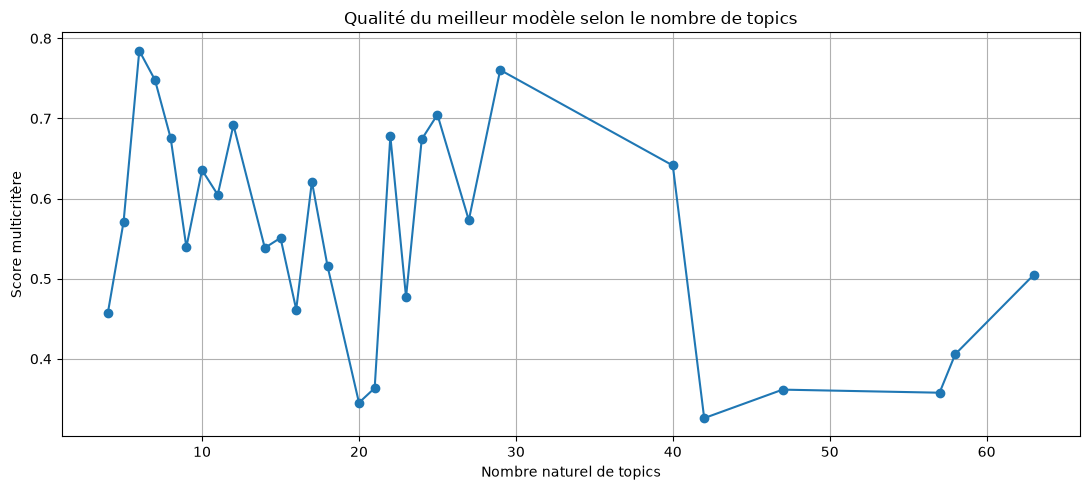

In [21]:
plt.figure(figsize=(11, 5))

plt.plot(
    meilleur_par_nombre_topics["n_topics"],
    meilleur_par_nombre_topics["score_global"],
    marker="o"
)
plt.xlabel("Nombre naturel de topics")
plt.ylabel("Score multicritère")
plt.title("Qualité du meilleur modèle selon le nombre de topics")

plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
def entrainer_configuration(
    params,
    seed,
    documents,
    embeddings_array
):
    """
    Entraîne une configuration BERTopic avec une seed donnée.
    """

    umap_model = UMAP(
        n_neighbors=int(params["n_neighbors"]),
        n_components=int(params["n_components"]),
        min_dist=0.0,
        metric="cosine",
        random_state=int(seed),
        low_memory=True
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=int(params["min_cluster_size"]),
        min_samples=int(params["min_samples"]),
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=False,
        core_dist_n_jobs=-1
    )

    vectorizer_model = CountVectorizer(
        min_df=2,
        max_df=0.8,
        #ngram_range=(1, 1)
    )

    ctfidf_model = ClassTfidfTransformer(
        reduce_frequent_words=True,
        bm25_weighting=True
    )

    model = BERTopic(
        language="french",
        hdbscan_model=hdbscan_model,
        umap_model=umap_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        calculate_probabilities=False,
        nr_topics=None,
        verbose=False
    )

    topics, _ = model.fit_transform(
        documents,
        embeddings=embeddings_array
    )

    return model, np.asarray(topics)

In [52]:
def calculer_stabilite(listes_labels):
    """
    Compare plusieurs exécutions d'une même configuration.

    Deux mesures :
    - ARI sur tous les documents ;
    - ARI sur les documents assignés dans les deux exécutions.
    """

    ari_tous = []
    ari_assignes = []
    parts_communes = []

    for labels_a, labels_b in combinations(
        listes_labels,
        2
    ):

        labels_a = np.asarray(labels_a)
        labels_b = np.asarray(labels_b)

        # ARI comprenant le label -1
        ari_tous.append(
            adjusted_rand_score(
                labels_a,
                labels_b
            )
        )

        # Documents assignés dans les deux modèles
        masque_commun = (
            (labels_a != -1)
            & (labels_b != -1)
        )

        parts_communes.append(
            masque_commun.mean()
        )

        labels_a_communs = labels_a[masque_commun]
        labels_b_communs = labels_b[masque_commun]

        condition_ari = (
            len(labels_a_communs) >= 2
            and len(np.unique(labels_a_communs)) >= 2
            and len(np.unique(labels_b_communs)) >= 2
        )

        if condition_ari:

            ari_assignes.append(
                adjusted_rand_score(
                    labels_a_communs,
                    labels_b_communs
                )
            )

        else:

            ari_assignes.append(np.nan)

    return {
        "stability_ari_all_mean": np.nanmean(ari_tous),
        "stability_ari_all_std": np.nanstd(ari_tous),
        "stability_ari_assigned_mean": np.nanmean(
            ari_assignes
        ),
        "stability_ari_assigned_std": np.nanstd(
            ari_assignes
        ),
        "common_assigned_share": np.nanmean(
            parts_communes
        )
    }

In [53]:
N_MEILLEURS_MODELES = 5

SEEDS = [1, 11, 35, 42, 73, 89]


top_configurations = (
    candidats
    .head(N_MEILLEURS_MODELES)
    .copy()
    .reset_index()
    .rename(columns={"index": "result_index"})
)


resultats_stabilite = []


for position, ligne in top_configurations.iterrows():

    params = {
        "n_neighbors": int(ligne["n_neighbors"]),
        "n_components": int(ligne["n_components"]),
        "min_cluster_size": int(
            ligne["min_cluster_size"]
        ),
        "min_samples": int(ligne["min_samples"])
    }

    print(
        f"\nConfiguration stable "
        f"{position + 1}/{len(top_configurations)}"
    )

    print(params)

    labels_par_seed = []
    nombres_topics = []
    taux_outliers = []

    for seed in SEEDS:

        print(f"  Seed {seed}")

        model_seed, labels_seed = (
            entrainer_configuration(
                params=params,
                seed=seed,
                documents=documents,
                embeddings_array=embeddings_array
            )
        )

        labels_par_seed.append(labels_seed)

        nombres_topics.append(
            len(
                np.unique(
                    labels_seed[labels_seed != -1]
                )
            )
        )

        taux_outliers.append(
            np.mean(labels_seed == -1)
        )

        del model_seed
        gc.collect()

    stabilite = calculer_stabilite(
        labels_par_seed
    )

    resultats_stabilite.append({
        "result_index": ligne["result_index"],
        **params,
        **stabilite,
        "mean_n_topics": np.mean(nombres_topics),
        "std_n_topics": np.std(nombres_topics),
        "mean_outlier_rate": np.mean(taux_outliers),
        "std_outlier_rate": np.std(taux_outliers)
    })


stabilite_df = pd.DataFrame(
    resultats_stabilite
)


display(
    stabilite_df.style.format({
        "stability_ari_all_mean": "{:.3f}",
        "stability_ari_all_std": "{:.3f}",
        "stability_ari_assigned_mean": "{:.3f}",
        "stability_ari_assigned_std": "{:.3f}",
        "common_assigned_share": "{:.1%}",
        "mean_n_topics": "{:.1f}",
        "std_n_topics": "{:.2f}",
        "mean_outlier_rate": "{:.1%}",
        "std_outlier_rate": "{:.1%}"
    })
)


Configuration stable 1/5
{'n_neighbors': 25, 'n_components': 10, 'min_cluster_size': 120, 'min_samples': 5}
  Seed 1
  Seed 11
  Seed 35
  Seed 42
  Seed 73
  Seed 89

Configuration stable 2/5
{'n_neighbors': 10, 'n_components': 5, 'min_cluster_size': 20, 'min_samples': 10}
  Seed 1
  Seed 11
  Seed 35
  Seed 42
  Seed 73
  Seed 89

Configuration stable 3/5
{'n_neighbors': 25, 'n_components': 10, 'min_cluster_size': 80, 'min_samples': 5}
  Seed 1
  Seed 11
  Seed 35
  Seed 42
  Seed 73
  Seed 89

Configuration stable 4/5
{'n_neighbors': 10, 'n_components': 10, 'min_cluster_size': 20, 'min_samples': 10}
  Seed 1
  Seed 11
  Seed 35
  Seed 42
  Seed 73
  Seed 89

Configuration stable 5/5
{'n_neighbors': 50, 'n_components': 5, 'min_cluster_size': 80, 'min_samples': 1}
  Seed 1
  Seed 11
  Seed 35
  Seed 42
  Seed 73
  Seed 89


,result_index,n_neighbors,n_components,min_cluster_size,min_samples,stability_ari_all_mean,stability_ari_all_std,stability_ari_assigned_mean,stability_ari_assigned_std,common_assigned_share,mean_n_topics,std_n_topics,mean_outlier_rate,std_outlier_rate
0,64,25,10,120,5,0.601,0.081,0.628,0.241,32.4%,5.2,0.90,60.9%,4.3%
1,12,10,5,20,10,0.436,0.048,0.762,0.117,28.2%,29.7,3.20,60.1%,4.3%
2,46,25,10,80,5,0.624,0.051,0.762,0.120,29.8%,6.7,1.25,63.5%,4.9%
3,15,10,10,20,10,0.291,0.287,0.526,0.382,32.4%,24.5,10.72,52.7%,17.5%
4,38,50,5,80,1,0.465,0.079,0.644,0.154,38.7%,9.7,2.56,51.2%,6.0%


In [54]:
top_configurations_stables = (
    top_configurations
    .merge(
        stabilite_df[
            [
                "result_index",
                "stability_ari_all_mean",
                "stability_ari_assigned_mean",
                "common_assigned_share",
                "mean_n_topics",
                "std_n_topics",
                "mean_outlier_rate"
            ]
        ],
        on="result_index",
        how="left"
    )
)


top_configurations_stables["stability_rank"] = (
    top_configurations_stables[
        "stability_ari_assigned_mean"
    ]
    .rank(pct=True)
    .fillna(0.5)
)


top_configurations_stables["score_final"] = (
    0.80
    * top_configurations_stables["score_global"]

    + 0.20
    * top_configurations_stables["stability_rank"]
)


top_configurations_stables = (top_configurations_stables.sort_values("score_final",ascending=False))


display(
    top_configurations_stables[
        [
            "n_neighbors",
            "n_components",
            "min_cluster_size",
            "min_samples",
            "n_topics",
            "outlier_rate",
            "coherence_cv",
            "silhouette_umap",
            "dbcv",
            "topic_diversity",
            "stability_ari_assigned_mean",
            "mean_n_topics",
            "std_n_topics",
            "score_global",
            "score_final"
        ]
    ]
    .style.format({
        "outlier_rate": "{:.1%}",
        "coherence_cv": "{:.3f}",
        "silhouette_umap": "{:.3f}",
        "dbcv": "{:.3f}",
        "topic_diversity": "{:.3f}",
        "stability_ari_assigned_mean": "{:.3f}",
        "mean_n_topics": "{:.1f}",
        "std_n_topics": "{:.2f}",
        "score_global": "{:.3f}",
        "score_final": "{:.3f}"
    })
)

,n_neighbors,n_components,min_cluster_size,min_samples,n_topics,outlier_rate,coherence_cv,silhouette_umap,dbcv,topic_diversity,stability_ari_assigned_mean,mean_n_topics,std_n_topics,score_global,score_final
1,10,5,20,10,29,62.2%,0.471,0.429,0.103,0.945,0.762,29.7,3.20,0.761,0.808
2,25,10,80,5,7,58.5%,0.503,0.345,0.064,1.000,0.762,6.7,1.25,0.748,0.758
0,25,10,120,5,6,60.2%,0.489,0.366,0.069,1.000,0.628,5.2,0.90,0.785,0.708
4,50,5,80,1,12,55.5%,0.483,0.360,-0.114,0.983,0.644,9.7,2.56,0.692,0.673
3,10,10,20,10,25,61.1%,0.456,0.439,0.104,0.964,0.526,24.5,10.72,0.705,0.604


In [55]:
meilleure_ligne = (top_configurations_stables.iloc[0])

best_params = {
    "n_neighbors": int(
        meilleure_ligne["n_neighbors"]
    ),
    "n_components": int(
        meilleure_ligne["n_components"]
    ),
    "min_cluster_size": int(
        meilleure_ligne["min_cluster_size"]
    ),
    "min_samples": int(
        meilleure_ligne["min_samples"]
    )
}


print("Meilleurs paramètres :")
print(best_params)

print(
    "\nNombre naturel de topics lors de la grille :",
    int(meilleure_ligne["n_topics"])
)

print(
    "Nombre moyen de topics sur plusieurs seeds :",
    round(meilleure_ligne["mean_n_topics"], 1)
)

Meilleurs paramètres :
{'n_neighbors': 10, 'n_components': 5, 'min_cluster_size': 20, 'min_samples': 10}

Nombre naturel de topics lors de la grille : 29
Nombre moyen de topics sur plusieurs seeds : 29.7


In [ ]:
candidats.to_csv("classement_modeles_bertopic.csv",index=False)
print("Exports terminés.")